In [2]:
import pandas as pd
data_set = pd.read_csv("vehicle-registration.csv", sep=";" )  
data_set.head()

,Date,Area Name,Electric,Plug-In Hybrid*,Hybrid,All Hybrids,Gas,Diesel,Electric: Difference,Plug-In Hybrid*: Difference,Hybrid: Difference,All Hybrids: Difference,Gas: Difference,Diesel: Difference,Year,Month
0,2024-07-31 00:00:00,Cherokee County,52.0,42.0,396.0,438.0,26973.0,2195.0,1.0,-3.0,7.0,4.0,30.0,-18.0,2024,7
1,2024-07-31 00:00:00,Jackson County,153.0,92.0,730.0,822.0,31087.0,2685.0,10.0,4.0,17.0,21.0,35.0,-23.0,2024,7
2,2024-09-30 00:00:00,Columbus County,36.0,26.0,414.0,440.0,42788.0,3197.0,-1.0,0.0,8.0,8.0,-171.0,25.0,2024,9
3,2024-09-30 00:00:00,Dare County,270.0,115.0,894.0,1009.0,36850.0,3010.0,16.0,1.0,-1.0,0.0,23.0,15.0,2024,9
4,2024-10-31 00:00:00,Dare County,228.0,106.0,1036.0,1142.0,38150.0,2719.0,10.0,0.0,12.0,12.0,78.0,-27.0,2024,10


In [3]:
fuel_cols = ["Electric", "Plug-In Hybrid*", "Hybrid", "All Hybrids", "Gas", "Diesel"]

# Total registrations per year, summed across every county and month
yearly_totals = data_set.groupby("Year")[fuel_cols].sum()
yearly_totals


,Electric,Plug-In Hybrid*,Hybrid,All Hybrids,Gas,Diesel
Year,,,,,,
2018,25307.0,26502.0,471482.0,497984.0,29929882.0,1781490.0
2019,111559.0,92874.0,1487749.0,1580623.0,92494218.0,5549777.0
2020,158648.0,101879.0,1531116.0,1632995.0,92462769.0,5696073.0
2021,242858.0,124583.0,1700205.0,1824788.0,94325864.0,5998512.0
2022,380952.0,167598.0,1932070.0,2099668.0,94626502.0,6203733.0
2023,622192.0,219195.0,2213926.0,2433121.0,95162666.0,6320763.0
2024,895704.0,286270.0,2757006.0,3043276.0,96617596.0,6148633.0
2025,1149848.0,354239.0,3706789.0,4061028.0,97181447.0,5479957.0
2026,663175.0,192842.0,2182772.0,2375614.0,47951208.0,2737865.0


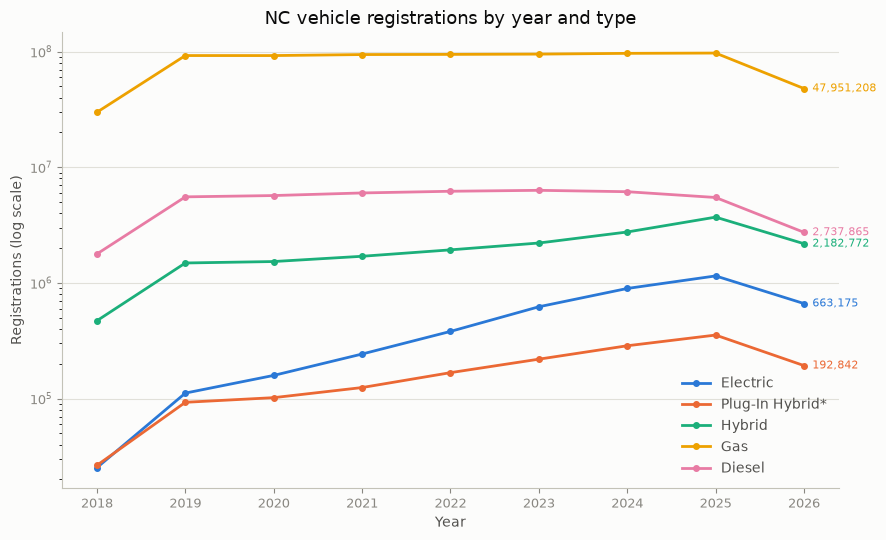

In [4]:
import matplotlib.pyplot as plt

# All Hybrids = Plug-In Hybrid* + Hybrid added together, so it's left out here
# to avoid double-counting a type alongside its own two components.
fuel_cols = ["Electric", "Plug-In Hybrid*", "Hybrid", "Gas", "Diesel"]
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]  # fixed order, one per type

yearly_totals = data_set.groupby("Year")[fuel_cols].sum()

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

for col, color in zip(fuel_cols, colors):
    ax.plot(yearly_totals.index, yearly_totals[col], color=color, linewidth=2,
             marker="o", markersize=4, label=col)
    last_x, last_y = yearly_totals.index[-1], yearly_totals[col].iloc[-1]
    ax.annotate(f"{last_y:,.0f}", (last_x, last_y), textcoords="offset points",
                xytext=(6, 0), fontsize=8, color=color, va="center")

# Log scale: Gas outnumbers Electric ~100x, so a linear axis would flatten
# every other line to near-zero. A single log axis keeps them all readable
# without resorting to a second (misleading) y-axis.
ax.set_yscale("log")
ax.set_ylabel("Registrations (log scale)", color="#52514e")
ax.set_xlabel("Year", color="#52514e")
ax.set_title("NC vehicle registrations by year and type", fontsize=13, color="#0b0b0b")

ax.grid(axis="y", which="major", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelsize=9)
ax.legend(frameon=False, labelcolor="#52514e")

plt.tight_layout()
plt.show()


In [5]:
fuel_cols = ["Electric", "Plug-In Hybrid*", "Hybrid", "Gas", "Diesel"]

durham = data_set[data_set["Area Name"] == "Durham County"].copy()
durham["Date"] = pd.to_datetime(durham["Date"])
durham = durham.sort_values("Date")

# Current snapshot: Durham's most recently reported month
latest = durham.iloc[-1]
print(f"Durham County as of {latest['Date'].date()}:")
print(latest[fuel_cols])

# Year-by-year trend for Durham ONLY, done correctly: take each year's
# last reported month as that year's snapshot, don't sum the months.
durham_yearly = durham.groupby("Year")[fuel_cols].last()
durham_yearly


Durham County as of 2026-06-30:
Electric             6073.0
Plug-In Hybrid*      1900.0
Hybrid              17197.0
Gas                190144.0
Diesel               5660.0
Name: 7008, dtype: object


,Electric,Plug-In Hybrid*,Hybrid,Gas,Diesel
Year,,,,,
2018,514.0,397.0,6510.0,191582.0,5576.0
2019,728.0,512.0,7171.0,197604.0,6063.0
2020,969.0,537.0,7500.0,194454.0,6176.0
2021,1519.0,710.0,8458.0,199405.0,6604.0
2022,2116.0,912.0,9209.0,196092.0,6641.0
2023,3317.0,1178.0,10717.0,197409.0,6608.0
2024,4410.0,1460.0,12840.0,194581.0,5903.0
2025,5596.0,1829.0,15687.0,190392.0,5685.0
2026,6073.0,1900.0,17197.0,190144.0,5660.0


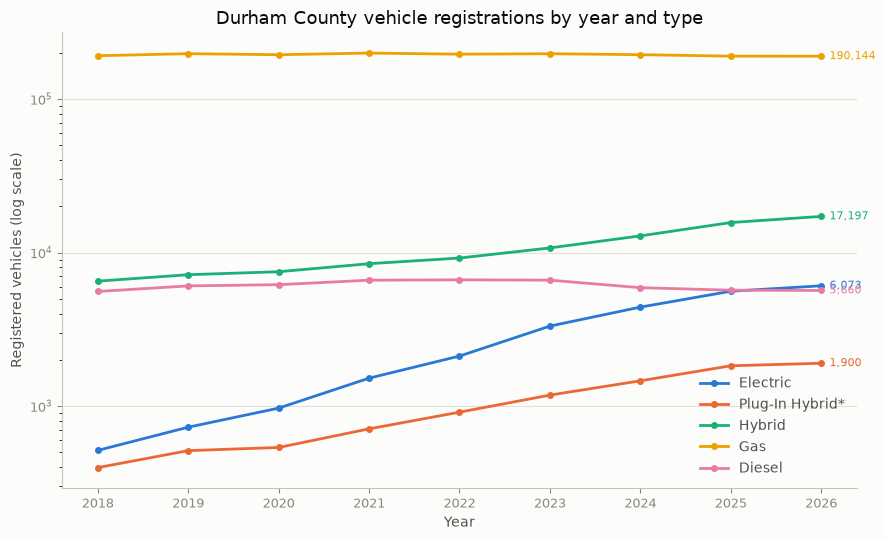

In [6]:
import matplotlib.pyplot as plt

fuel_cols = ["Electric", "Plug-In Hybrid*", "Hybrid", "Gas", "Diesel"]
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]  # fixed order, one per type

# Durham only, and .last() per year (end-of-year snapshot) — NOT .sum(),
# since these columns are running totals, not monthly new-registration counts.
durham = data_set[data_set["Area Name"] == "Durham County"].copy()
durham["Date"] = pd.to_datetime(durham["Date"])
durham = durham.sort_values("Date")
durham_yearly = durham.groupby("Year")[fuel_cols].last()

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

for col, color in zip(fuel_cols, colors):
    ax.plot(durham_yearly.index, durham_yearly[col], color=color, linewidth=2,
             marker="o", markersize=4, label=col)
    last_x, last_y = durham_yearly.index[-1], durham_yearly[col].iloc[-1]
    ax.annotate(f"{last_y:,.0f}", (last_x, last_y), textcoords="offset points",
                xytext=(6, 0), fontsize=8, color=color, va="center")

# Log scale: Gas outnumbers Electric ~30x in Durham, so a linear axis would
# flatten every other line near zero. One log axis, not a second y-axis.
ax.set_yscale("log")
ax.set_ylabel("Registered vehicles (log scale)", color="#52514e")
ax.set_xlabel("Year", color="#52514e")
ax.set_title("Durham County vehicle registrations by year and type", fontsize=13, color="#0b0b0b")

ax.grid(axis="y", which="major", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelsize=9)
ax.legend(frameon=False, labelcolor="#52514e")

plt.tight_layout()
plt.show()
